In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

def load_and_preprocess_data(filename='exams.csv'):
    """Load and preprocess the exam data with min-max normalization."""
    print("1. Loading and Preprocessing Data")
    print("=" * 50)
    
    # Load the data
    data = pd.read_csv(filename)
    print(f"Dataset shape: {data.shape}")
    print(f"Columns: {list(data.columns)}")
    print("\nFirst 5 rows:")
    print(data.head())
    
    # Separate features and target
    X = data[['exam_1', 'exam_2']].values
    y = data['admitted'].values
    
    print(f"\nData ranges before normalization:")
    print(f"Exam 1: [{X[:, 0].min():.2f}, {X[:, 0].max():.2f}]")
    print(f"Exam 2: [{X[:, 1].min():.2f}, {X[:, 1].max():.2f}]")
    
    # Apply min-max normalization
    scaler = MinMaxScaler()
    X_normalized = scaler.fit_transform(X)
    
    print(f"\nData ranges after normalization:")
    print(f"Exam 1: [{X_normalized[:, 0].min():.2f}, {X_normalized[:, 0].max():.2f}]")
    print(f"Exam 2: [{X_normalized[:, 1].min():.2f}, {X_normalized[:, 1].max():.2f}]")
    
    # Add bias term (intercept)
    X_with_bias = np.column_stack([np.ones(X_normalized.shape[0]), X_normalized])
    
    print(f"\nClass distribution:")
    print(f"Admitted (1): {np.sum(y == 1)}")
    print(f"Not admitted (0): {np.sum(y == 0)}")
    
    return X, X_normalized, X_with_bias, y, scaler

In [2]:
def visualize_data(X, y, title="Exam Scores Visualization"):
    """Plot exam scores colored by admission status."""
    plt.figure(figsize=(8, 6))
    
    # Plot admitted students in green
    admitted_mask = y == 1
    plt.scatter(X[admitted_mask, 0], X[admitted_mask, 1], 
                c='green', marker='o', label='Admitted', alpha=0.7)
    
    # Plot non-admitted students in red
    not_admitted_mask = y == 0
    plt.scatter(X[not_admitted_mask, 0], X[not_admitted_mask, 1], 
                c='red', marker='o', label='Not Admitted', alpha=0.7)
    
    plt.xlabel('First Exam Score')
    plt.ylabel('Second Exam Score')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [3]:
def sigmoid(z):
    """
    Compute the sigmoid function.
    Args:
        z: Input value or array
    Returns:
        Sigmoid of z
    """
    # Clip z to prevent overflow
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def compute_cost(theta, X, y):
    """
    Compute the logistic regression cost function.
    Args:
        theta: Parameters vector
        X: Feature matrix with bias term
        y: Target vector
    Returns:
        Cost value
    """
    m = len(y)
    h = sigmoid(X.dot(theta))
    
    # Add small epsilon to prevent log(0)
    epsilon = 1e-15
    h = np.clip(h, epsilon, 1 - epsilon)
    
    cost = -(1/m) * (y.dot(np.log(h)) + (1-y).dot(np.log(1-h)))
    return cost

def gradient_descent(X, y, alpha=0.01, num_iterations=10000):
    """
    Perform gradient descent to find optimal parameters.
    Args:
        X: Feature matrix with bias term
        y: Target vector
        alpha: Learning rate
        num_iterations: Number of iterations
    Returns:
        theta: Optimal parameters
        costs: Cost history
    """
    m, n = X.shape
    theta = np.zeros(n)
    costs = []
    
    for i in range(num_iterations):
        # Forward propagation
        h = sigmoid(X.dot(theta))
        
        # Compute cost
        cost = compute_cost(theta, X, y)
        costs.append(cost)
        
        # Gradient computation
        gradient = (1/m) * X.T.dot(h - y)
        
        # Update parameters
        theta = theta - alpha * gradient
        
        # Print progress
        if i % 1000 == 0:
            print(f"Iteration {i}, Cost: {cost:.6f}")
    
    return theta, costs

def plot_cost_function(costs):
    """Plot the cost function over iterations."""
    plt.figure(figsize=(10, 6))
    plt.plot(costs)
    plt.title('Cost Function Over Iterations')
    plt.xlabel('Iterations')
    plt.ylabel('Cost')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print(f"Initial cost: {costs[0]:.6f}")
    print(f"Final cost: {costs[-1]:.6f}")
    print(f"Cost reduction: {costs[0] - costs[-1]:.6f}")

def plot_decision_boundary(X_normalized, y, theta, scaler):
    """Plot the decision boundary along with data points."""
    plt.figure(figsize=(8, 6))
    
    # Plot data points
    admitted_mask = y == 1
    plt.scatter(X_normalized[admitted_mask, 0], X_normalized[admitted_mask, 1], 
                c='green', marker='o', label='Admitted', alpha=0.7)
    
    not_admitted_mask = y == 0
    plt.scatter(X_normalized[not_admitted_mask, 0], X_normalized[not_admitted_mask, 1], 
                c='red', marker='o', label='Not Admitted', alpha=0.7)
    
    if theta[2] != 0:  # Avoid division by zero
        x_boundary = np.linspace(0, 1, 100)
        y_boundary = -(theta[0] + theta[1] * x_boundary) / theta[2]
        plt.plot(x_boundary, y_boundary, 'b-', linewidth=2, label='Decision Boundary')
    
    plt.xlabel('First Exam Score (Normalized)')
    plt.ylabel('Second Exam Score (Normalized)')
    plt.title('Decision Boundary')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.show()

def predict(theta, X):
    """Make predictions using the trained model."""
    probabilities = sigmoid(X.dot(theta))
    return (probabilities >= 0.5).astype(int)

def evaluate_model(theta, X, y):
    """Evaluate the model performance."""
    predictions = predict(theta, X)
    accuracy = accuracy_score(y, predictions)
    
    print(f"Model Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    
    # Confusion matrix-like analysis
    correct_predictions = np.sum(predictions == y)
    total_predictions = len(y)
    
    print(f"Correct predictions: {correct_predictions}/{total_predictions}")
    
    return accuracy, predictions

def test_specific_cases(theta, scaler):
    """Test specific cases as required by the assignment."""
    print("\nTesting specific cases:")
    print("=" * 30)
    
    # Test cases: {55, 70, 1} and {40, 60, 0}
    test_cases = np.array([[55, 70], [40, 60]])
    expected = np.array([1, 0])
    
    test_normalized = scaler.transform(test_cases)
    test_with_bias = np.column_stack([np.ones(test_normalized.shape[0]), test_normalized])
    
    probabilities = sigmoid(test_with_bias.dot(theta))
    predictions = (probabilities >= 0.5).astype(int)
    
    for i, (case, prob, pred, exp) in enumerate(zip(test_cases, probabilities, predictions, expected)):
        print(f"Test case {i+1}: Exam scores {case}")
        print(f"  Probability: {prob:.4f}")
        print(f"  Prediction: {pred} (Expected: {exp})")
        print(f"  Correct: {'✓' if pred == exp else '✗'}")

In [4]:
def sklearn_logistic_regression(X_normalized, y, test_cases_normalized):
    """Implement logistic regression using scikit-learn."""
    print("\n4. Logistic Regression using Scikit-Learn")
    print("=" * 50)
    
    # Create and train the model
    model = LogisticRegression(random_state=42, max_iter=1000)
    model.fit(X_normalized, y)
    
    # Make predictions
    predictions = model.predict(X_normalized)
    probabilities = model.predict_proba(X_normalized)[:, 1]
    
    # Evaluate performance
    accuracy = accuracy_score(y, predictions)
    print(f"Scikit-Learn Model Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    
    # Test specific cases
    test_cases = np.array([[55, 70], [40, 60]])
    test_normalized = scaler.transform(test_cases)
    test_predictions = model.predict(test_normalized)
    test_probabilities = model.predict_proba(test_normalized)[:, 1]
    
    print("\nScikit-Learn predictions for test cases:")
    expected = np.array([1, 0])
    for i, (case, prob, pred, exp) in enumerate(zip(test_cases, test_probabilities, test_predictions, expected)):
        print(f"Test case {i+1}: Exam scores {case}")
        print(f"  Probability: {prob:.4f}")
        print(f"  Prediction: {pred} (Expected: {exp})")
        print(f"  Correct: {'✓' if pred == exp else '✗'}")
    
    return model, accuracy

CSCI4734 - Machine Learning Assignment 2
Logistic Regression Implementation
1. Loading and Preprocessing Data
Dataset shape: (100, 3)
Columns: ['exam_1', 'exam_2', 'admitted']

First 5 rows:
      exam_1     exam_2  admitted
0  34.623660  78.024693         0
1  30.286711  43.894998         0
2  35.847409  72.902198         0
3  60.182599  86.308552         1
4  79.032736  75.344376         1

Data ranges before normalization:
Exam 1: [30.06, 99.83]
Exam 2: [30.60, 98.87]

Data ranges after normalization:
Exam 1: [0.00, 1.00]
Exam 2: [0.00, 1.00]

Class distribution:
Admitted (1): 60
Not admitted (0): 40

2. Data Visualization


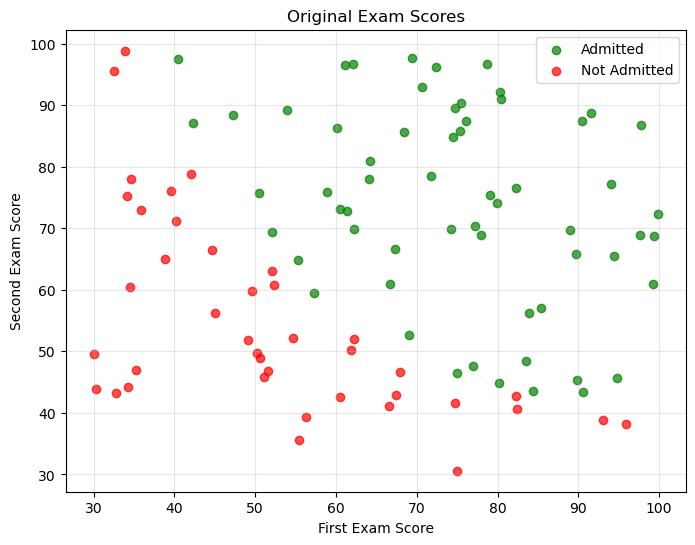

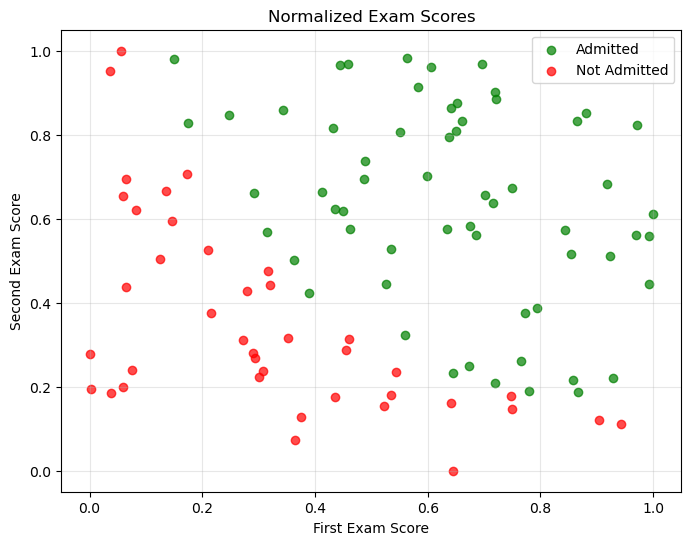


3. Logistic Regression from Scratch

Training the model...
Iteration 0, Cost: 0.693147
Iteration 1000, Cost: 0.371325
Iteration 2000, Cost: 0.303669
Iteration 3000, Cost: 0.273520
Iteration 4000, Cost: 0.256318
Iteration 5000, Cost: 0.245165
Iteration 6000, Cost: 0.237352
Iteration 7000, Cost: 0.231589
Iteration 8000, Cost: 0.227177
Iteration 9000, Cost: 0.223705

Optimal parameters:
θ₀ (bias): -8.185800
θ₁ (exam_1): 9.347007
θ₂ (exam_2): 8.766504

Cost Function Analysis:


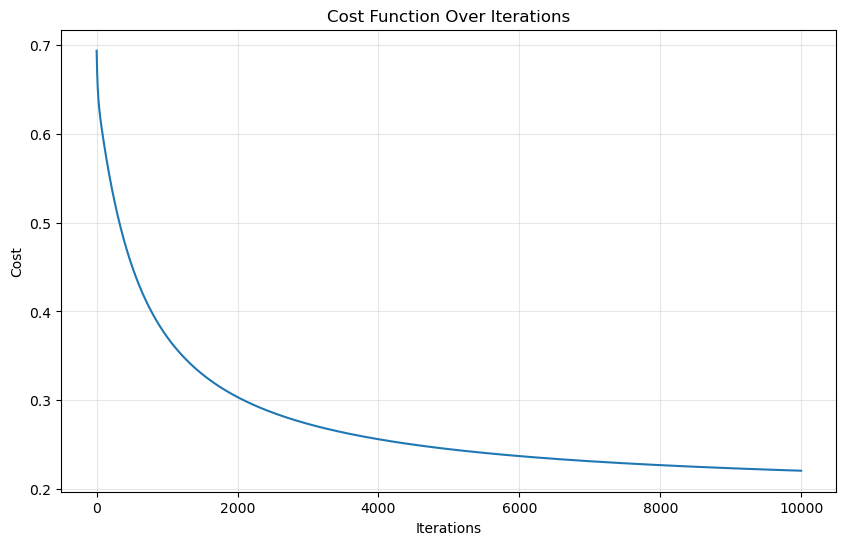

Initial cost: 0.693147
Final cost: 0.220915
Cost reduction: 0.472232

Decision Boundary Visualization:


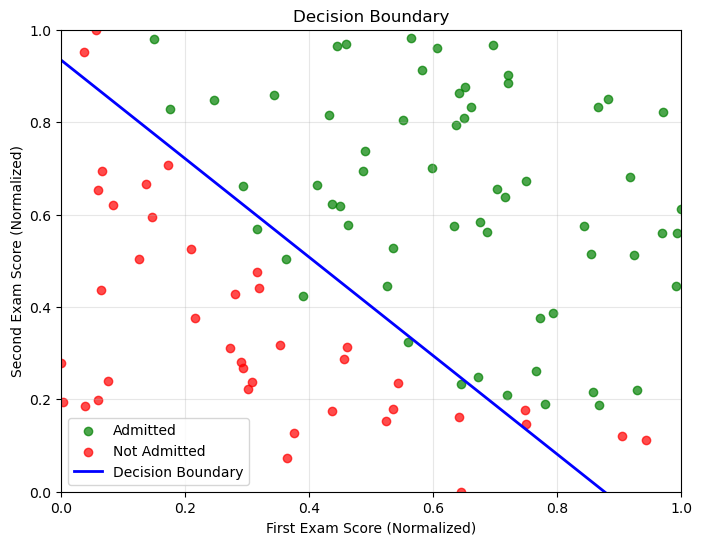


Model Evaluation:
Model Accuracy: 0.8900 (89.00%)
Correct predictions: 89/100

Testing specific cases:
Test case 1: Exam scores [55 70]
  Probability: 0.5535
  Prediction: 1 (Expected: 1)
  Correct: ✓
Test case 2: Exam scores [40 60]
  Probability: 0.0440
  Prediction: 0 (Expected: 0)
  Correct: ✓

4. Logistic Regression using Scikit-Learn
Scikit-Learn Model Accuracy: 0.9300 (93.00%)

Scikit-Learn predictions for test cases:
Test case 1: Exam scores [55 70]
  Probability: 0.5492
  Prediction: 1 (Expected: 1)
  Correct: ✓
Test case 2: Exam scores [40 60]
  Probability: 0.2916
  Prediction: 0 (Expected: 0)
  Correct: ✓

FINAL RESULTS SUMMARY
From Scratch Accuracy: 0.8900 (89.00%)
Scikit-Learn Accuracy: 0.9300 (93.00%)
Difference: 0.0400

The assignment has been completed successfully!
Remember to create a report explaining each step and the results.


In [5]:
if __name__ == "__main__":
    print("CSCI4734 - Machine Learning Assignment 2")
    print("Logistic Regression Implementation")
    print("=" * 60)
    
    # Load and preprocess data
    X_original, X_normalized, X_with_bias, y, scaler = load_and_preprocess_data()
    
    # Visualization
    print("\n2. Data Visualization")
    print("=" * 50)
    visualize_data(X_original, y, "Original Exam Scores")
    visualize_data(X_normalized, y, "Normalized Exam Scores")
    
    # Implement logistic regression from scratch
    print("\n3. Logistic Regression from Scratch")
    print("=" * 50)
    
    print("\nTraining the model...")
    theta, costs = gradient_descent(X_with_bias, y, alpha=0.1, num_iterations=10000)
    
    print(f"\nOptimal parameters:")
    print(f"θ₀ (bias): {theta[0]:.6f}")
    print(f"θ₁ (exam_1): {theta[1]:.6f}")
    print(f"θ₂ (exam_2): {theta[2]:.6f}")
    
    # Plot cost function
    print("\nCost Function Analysis:")
    plot_cost_function(costs)
    
    # Plot decision boundary
    print("\nDecision Boundary Visualization:")
    plot_decision_boundary(X_normalized, y, theta, scaler)
    
    # Evaluate model
    print("\nModel Evaluation:")
    print("=" * 30)
    accuracy_scratch, predictions_scratch = evaluate_model(theta, X_with_bias, y)
    
    # Test specific cases
    test_specific_cases(theta, scaler)
    
    # Compare with scikit-learn
    sklearn_model, accuracy_sklearn = sklearn_logistic_regression(X_normalized, y, scaler)
    
    # Final comparison
    print("\n" + "=" * 60)
    print("FINAL RESULTS SUMMARY")
    print("=" * 60)
    print(f"From Scratch Accuracy: {accuracy_scratch:.4f} ({accuracy_scratch*100:.2f}%)")
    print(f"Scikit-Learn Accuracy: {accuracy_sklearn:.4f} ({accuracy_sklearn*100:.2f}%)")
    print(f"Difference: {abs(accuracy_scratch - accuracy_sklearn):.4f}")
    
    print("\nThe assignment has been completed successfully!")
    print("Remember to create a report explaining each step and the results.")